#**KNN**

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [3]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score,accuracy_score,roc_curve,auc

**Reading Dataset from drive**

In [4]:
data = pd.read_csv('/content/drive/My Drive/Sem5/new_ml/a3/spambase_csv.csv')
data.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


#**EDA**

**(i) Missing values**

In [5]:
data.isnull().sum()

,0
word_freq_make,0
word_freq_address,0
word_freq_all,0
word_freq_3d,0
word_freq_our,0
word_freq_over,0
word_freq_remove,0
word_freq_internet,0
word_freq_order,0
word_freq_mail,0


**(ii) Handle Outliers**

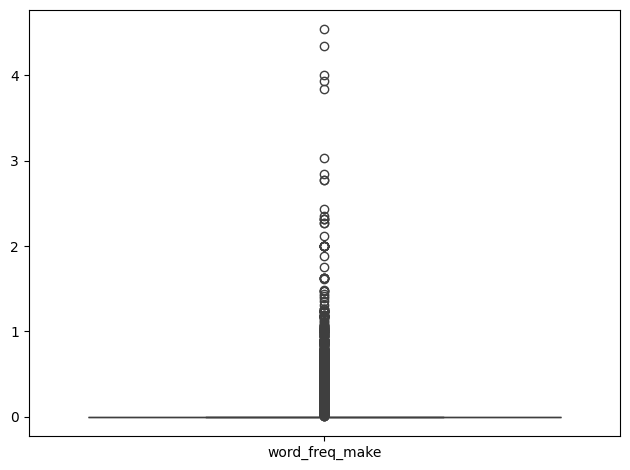

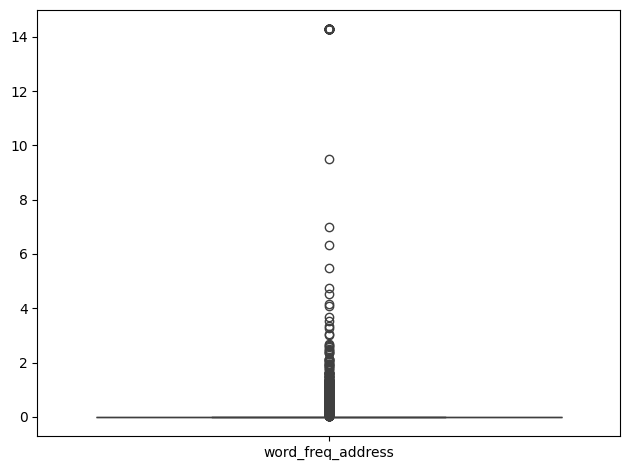

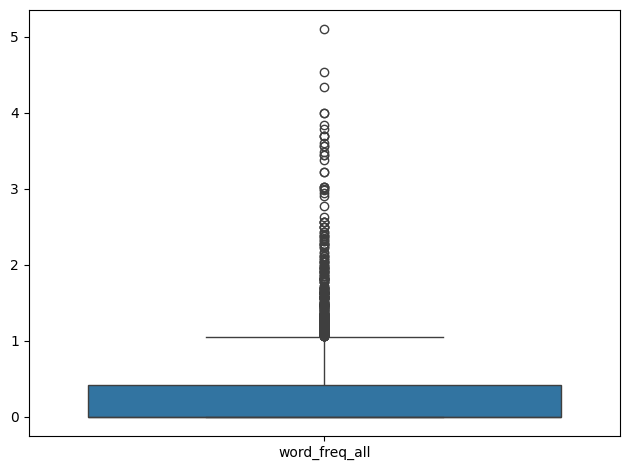

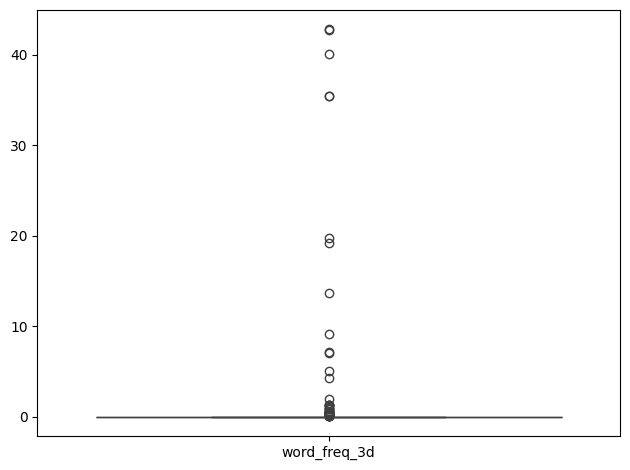

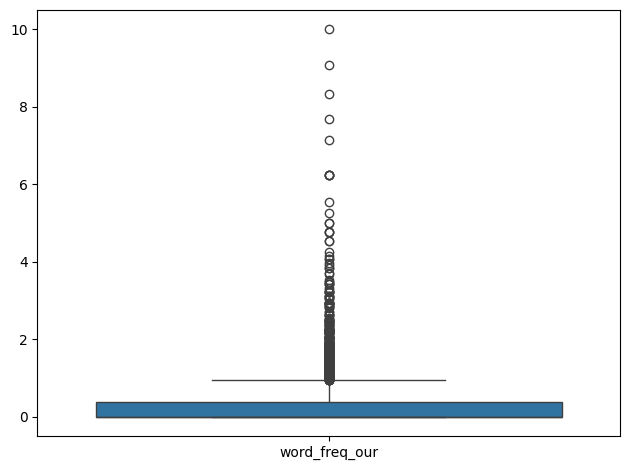

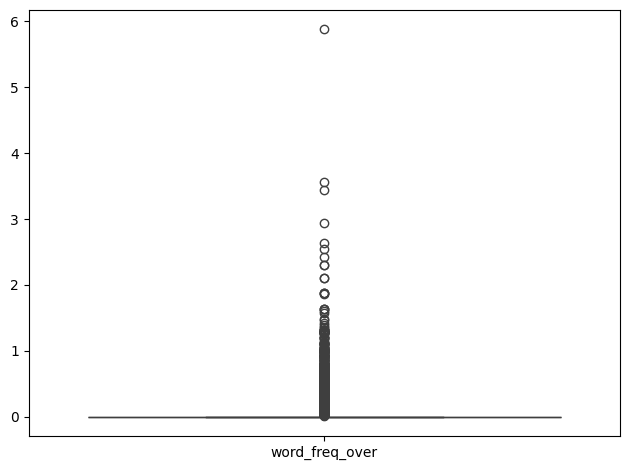

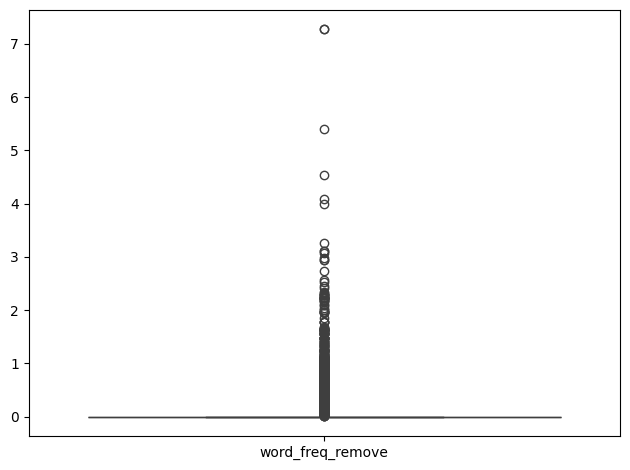

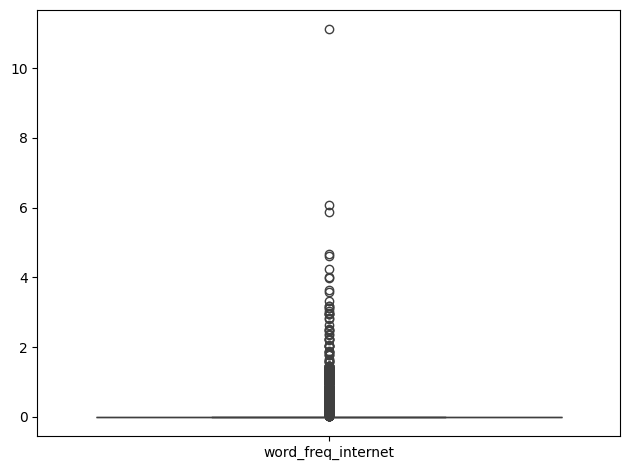

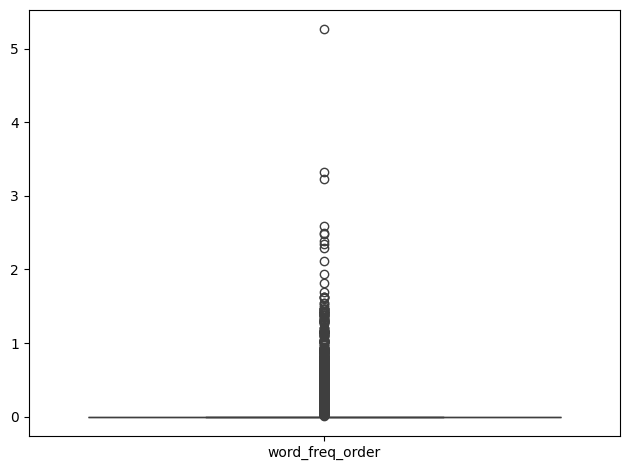

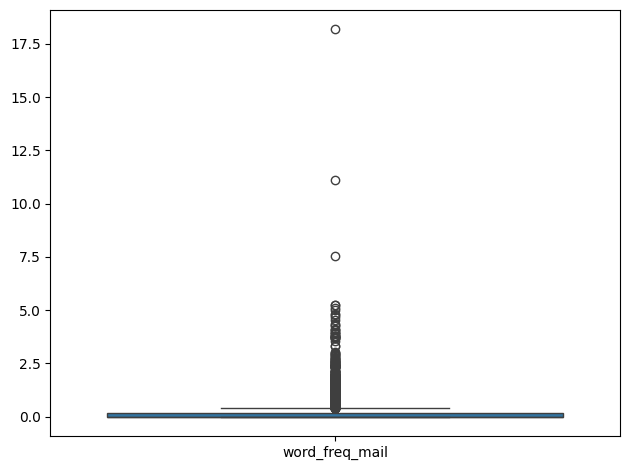

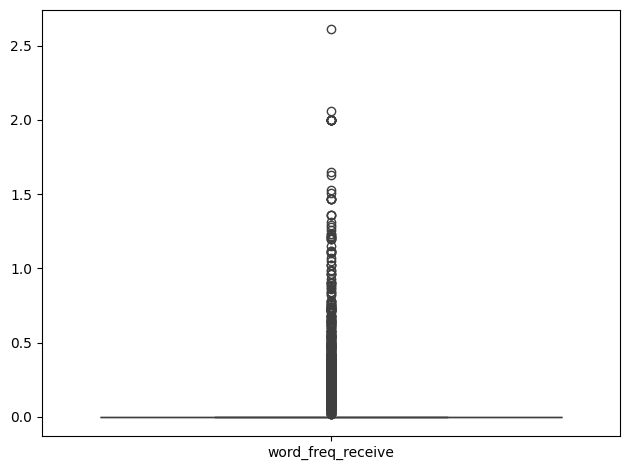

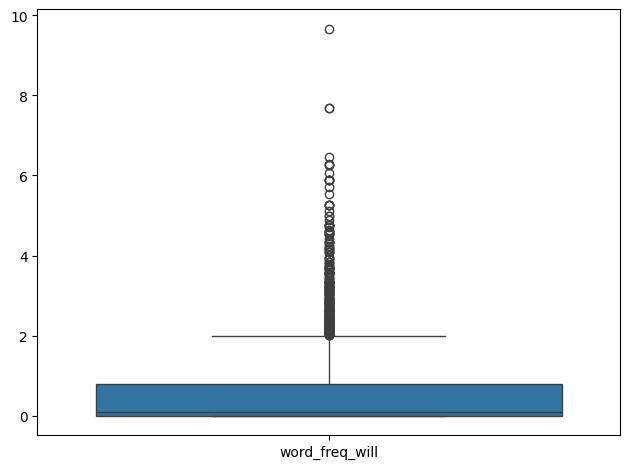

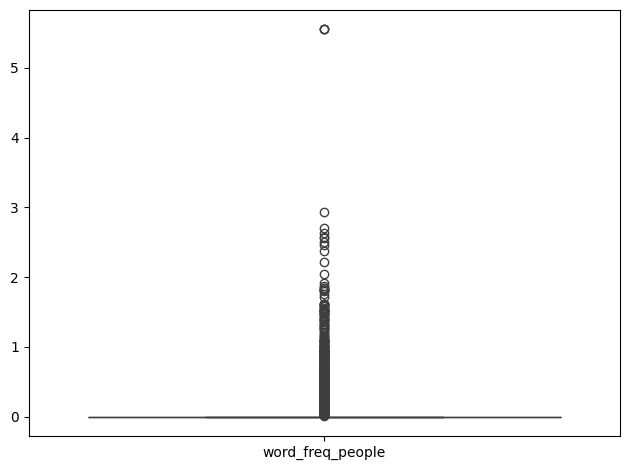

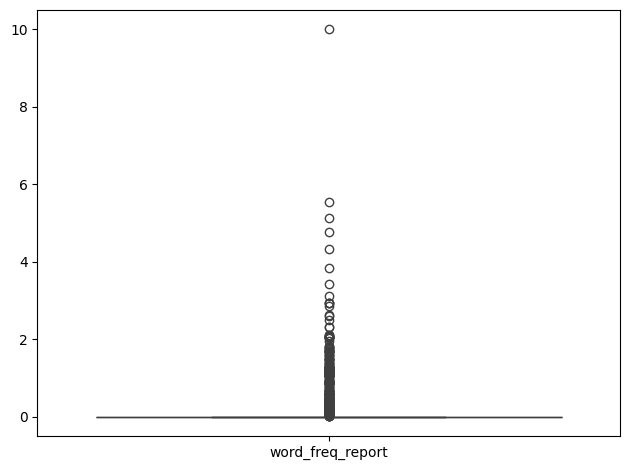

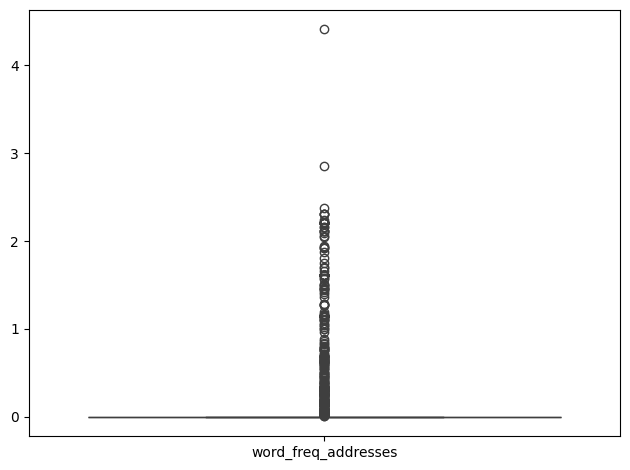

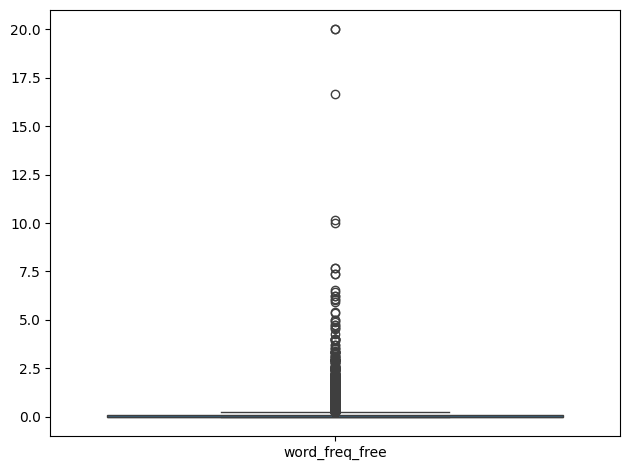

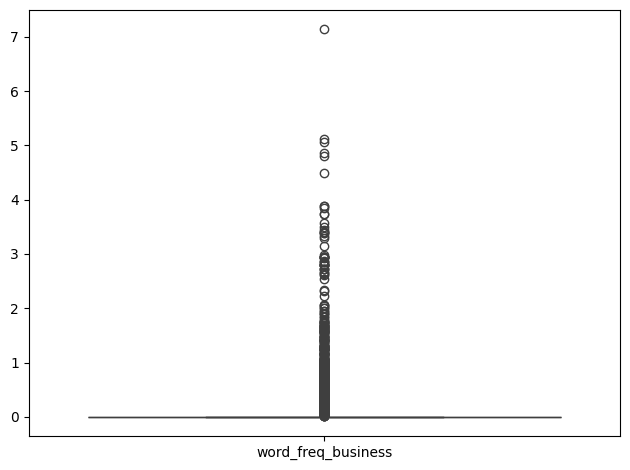

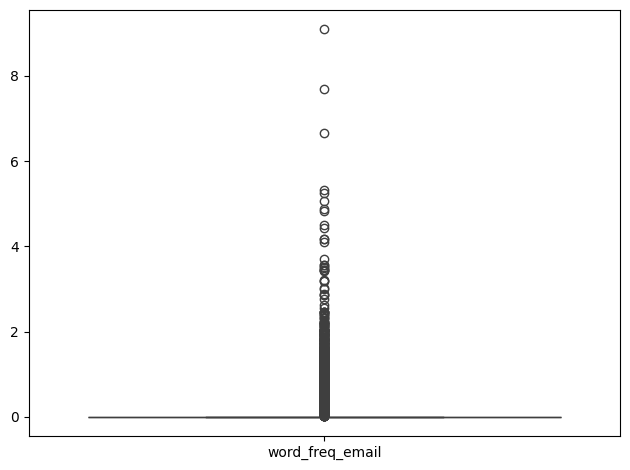

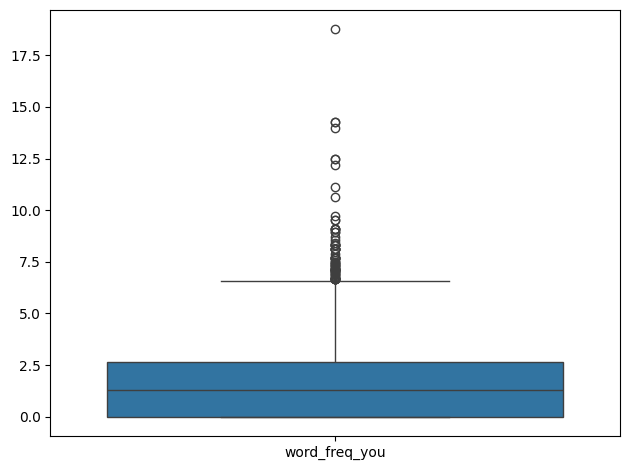

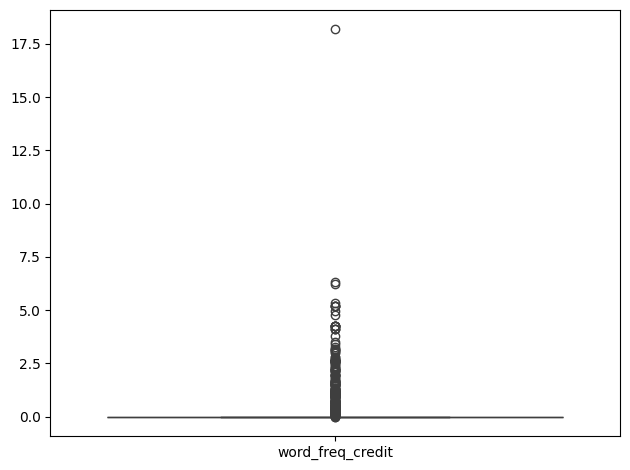

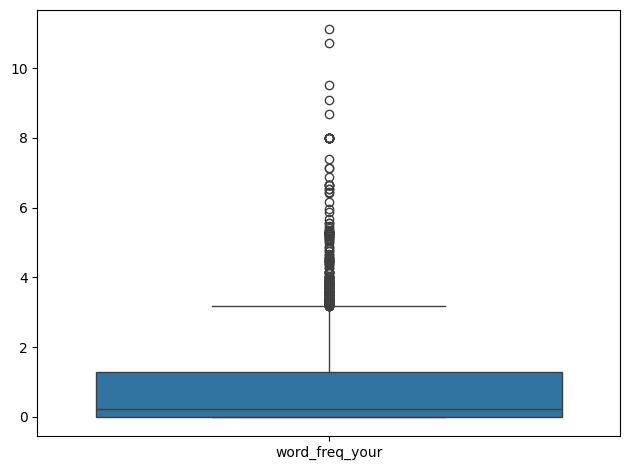

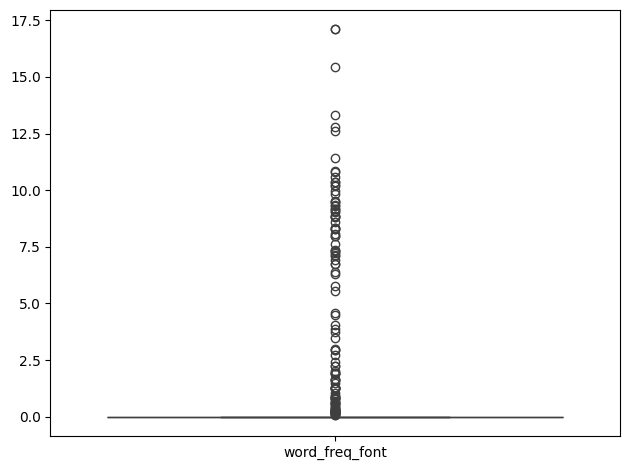

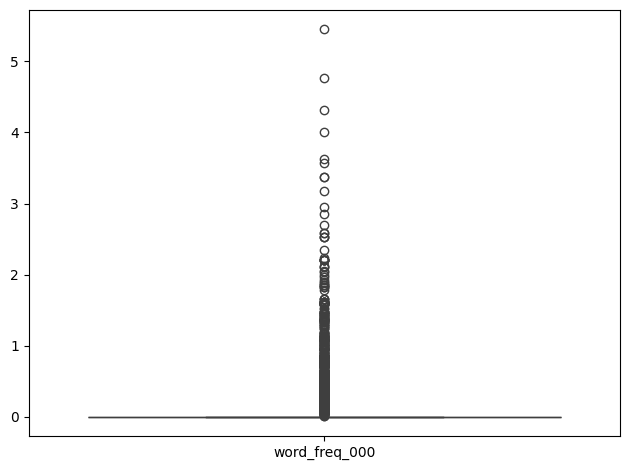

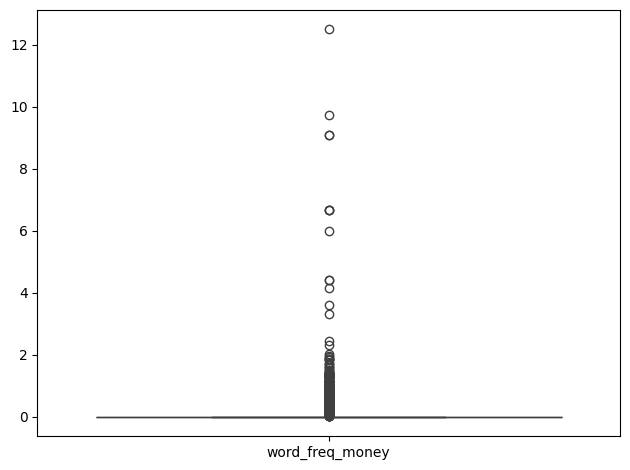

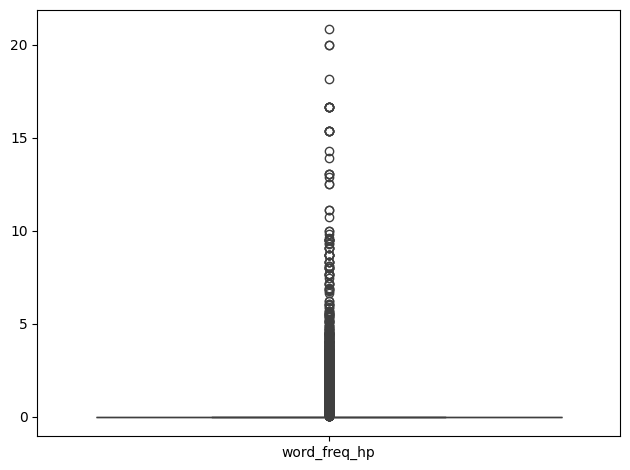

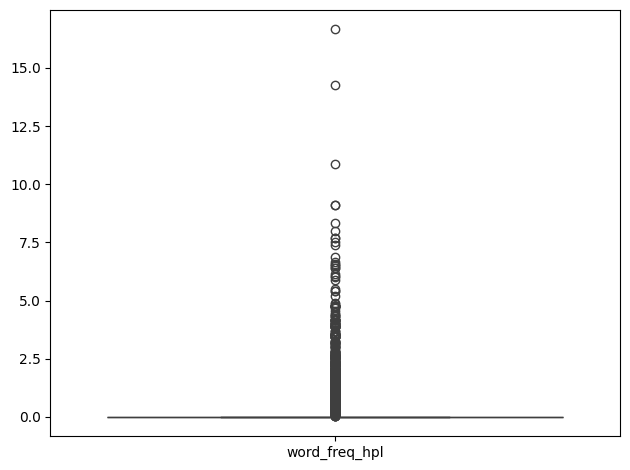

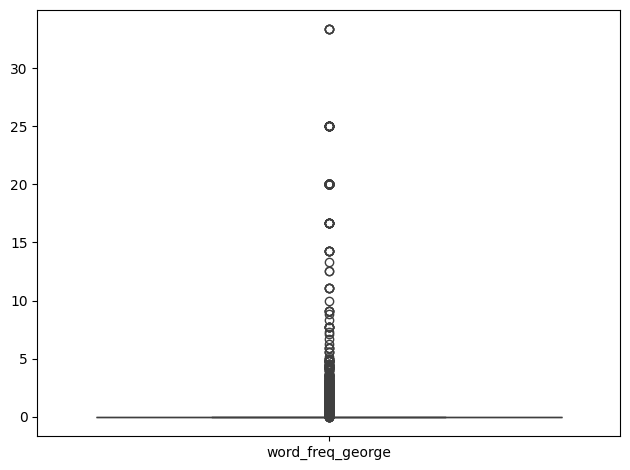

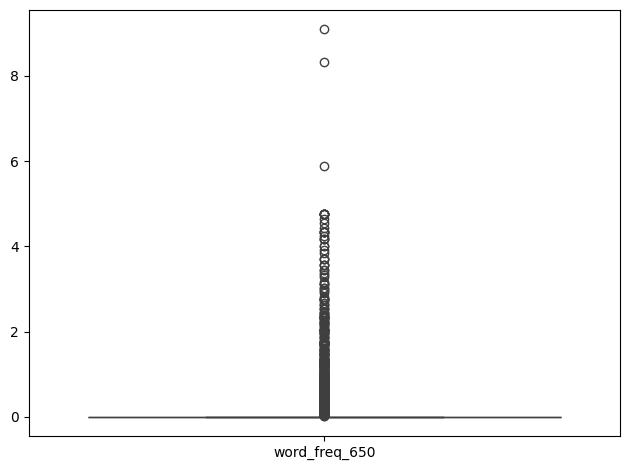

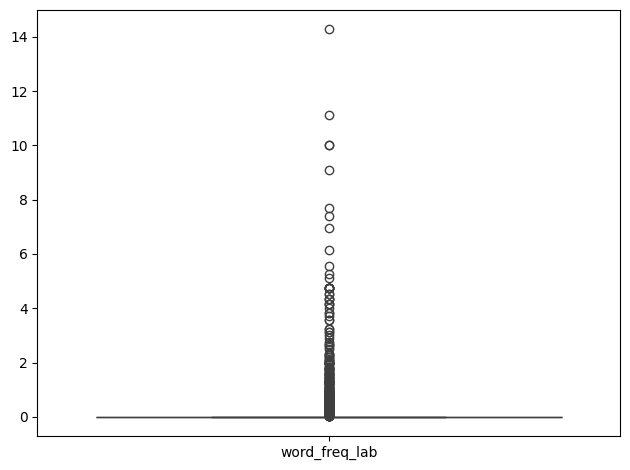

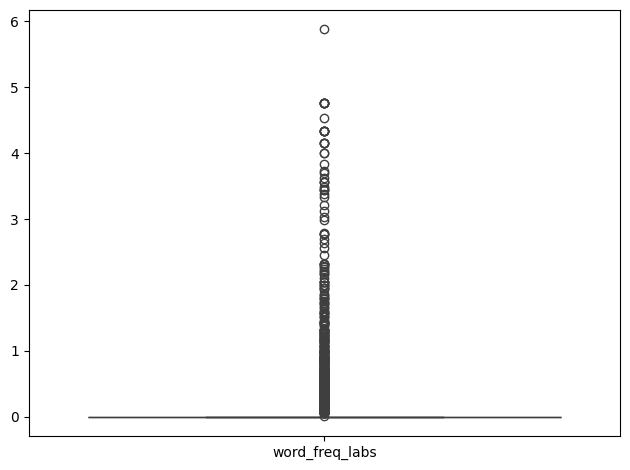

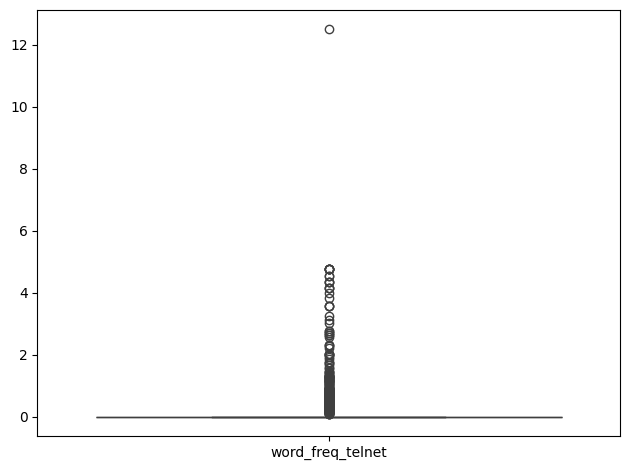

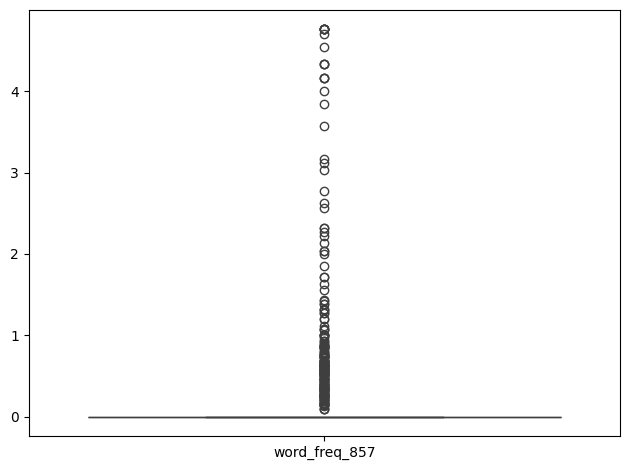

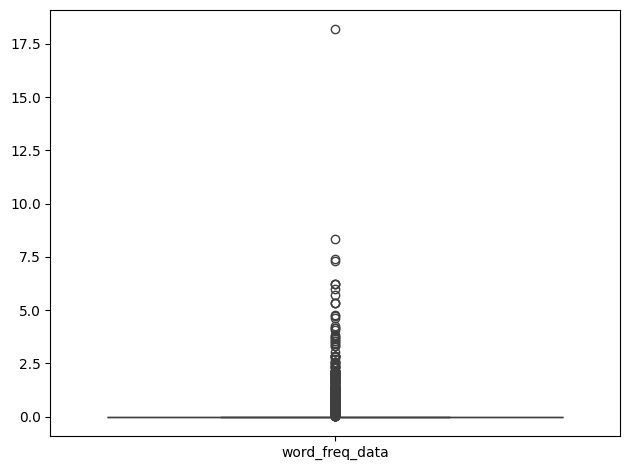

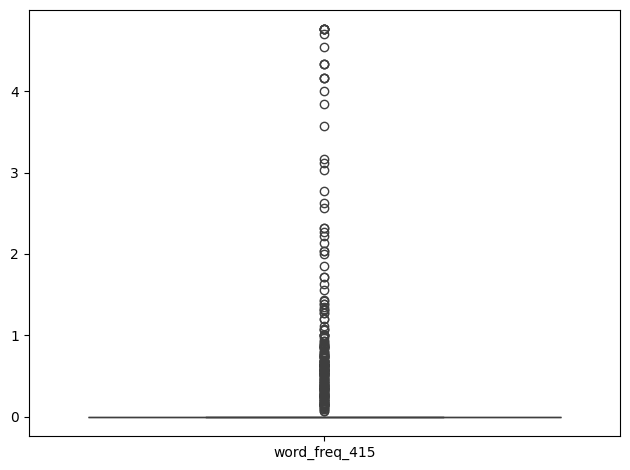

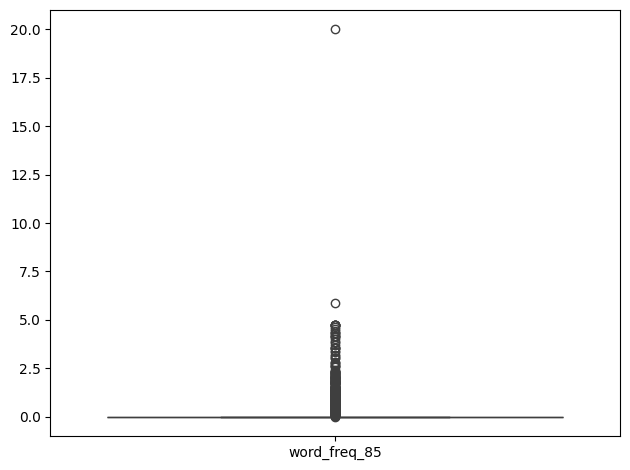

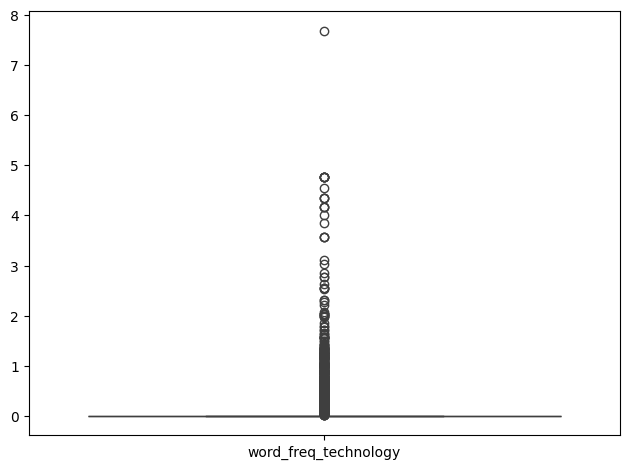

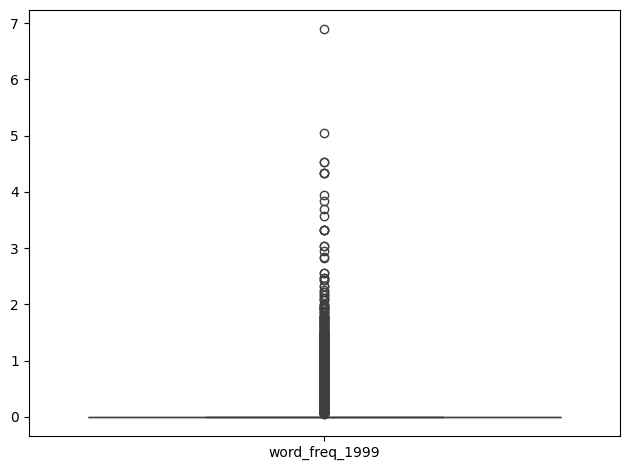

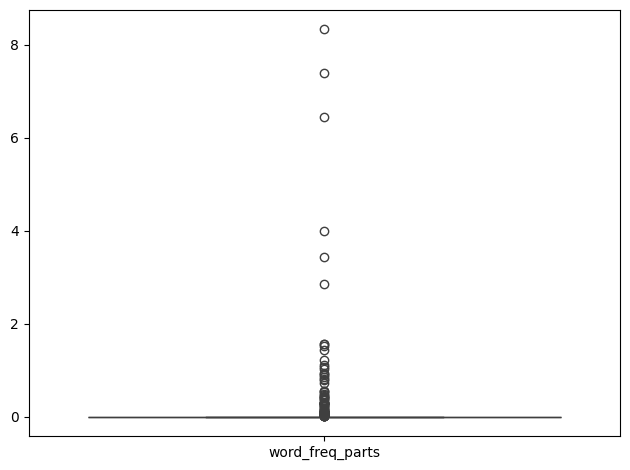

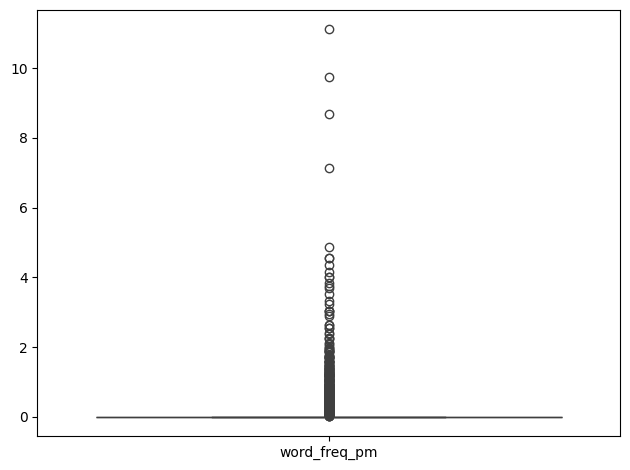

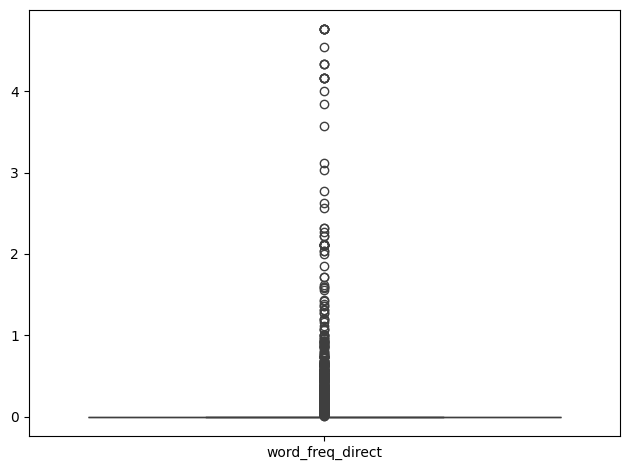

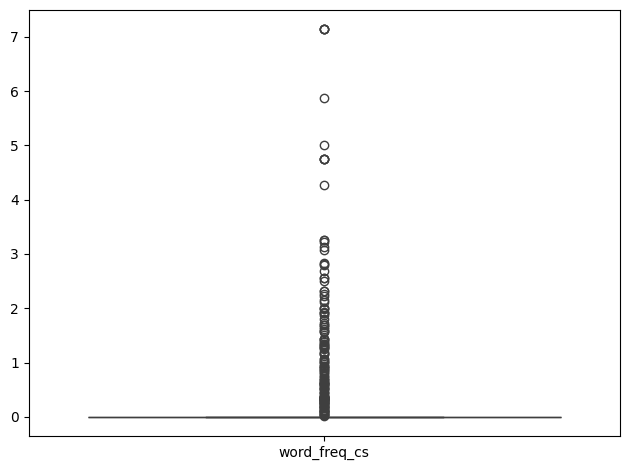

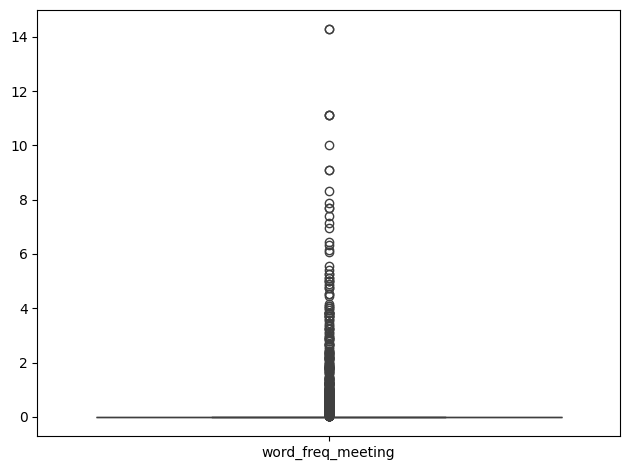

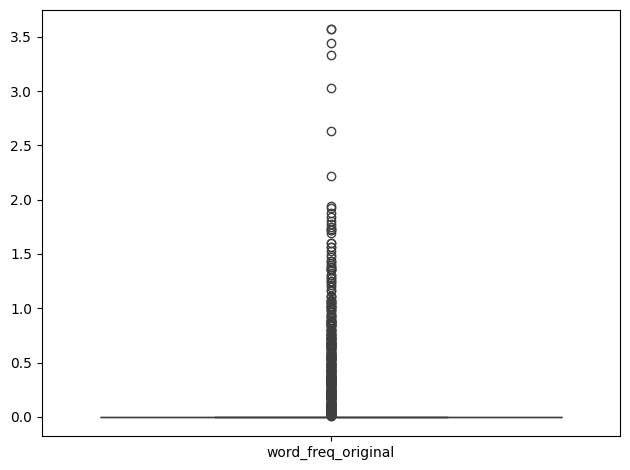

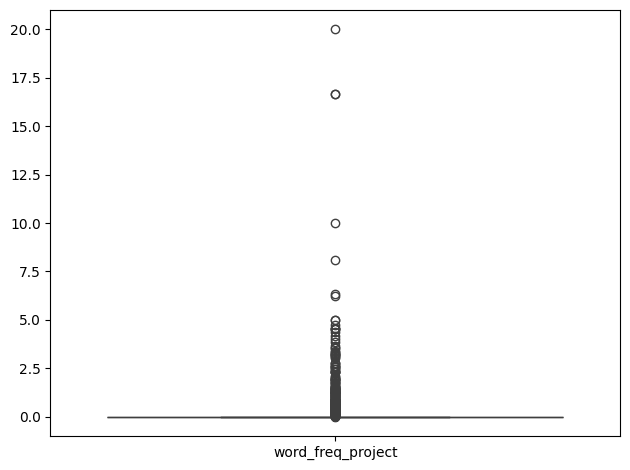

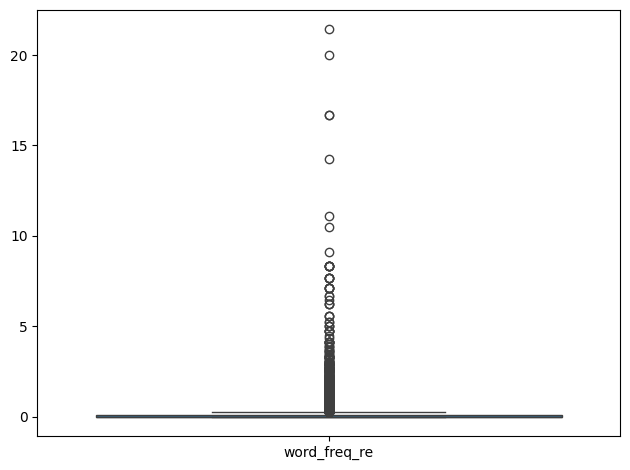

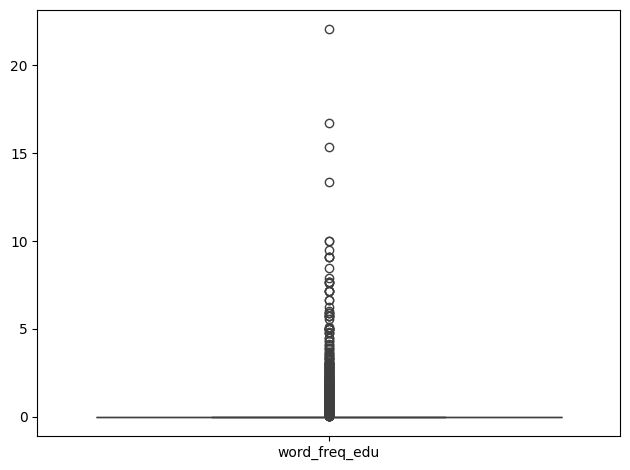

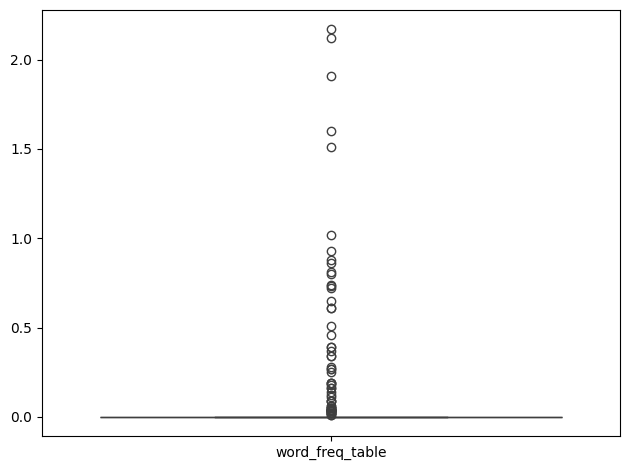

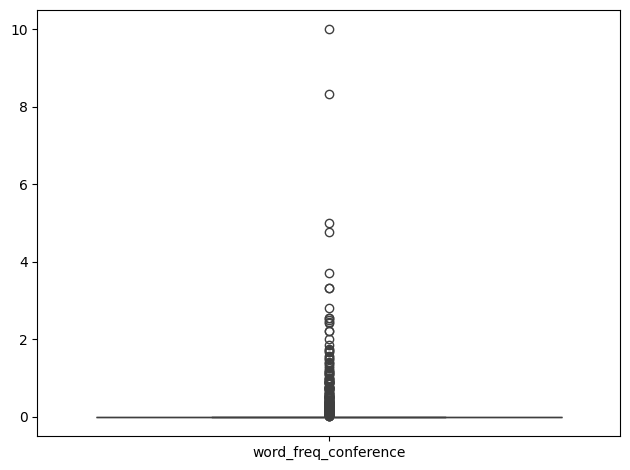

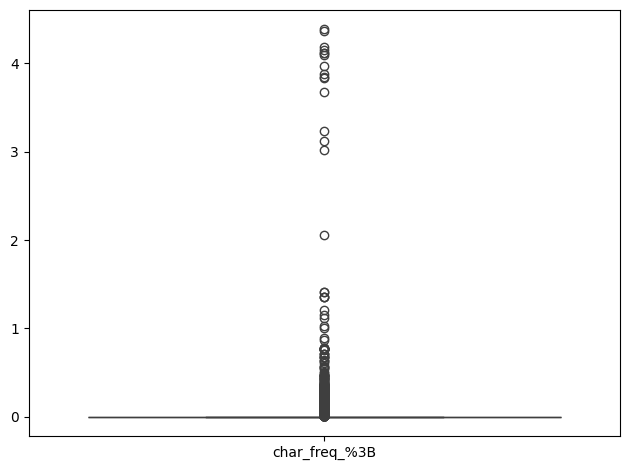

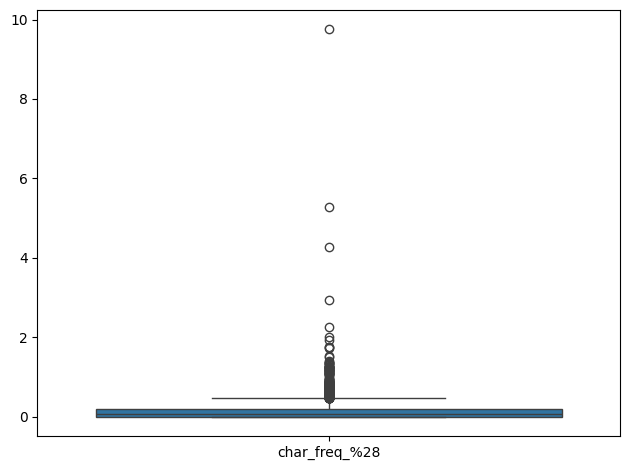

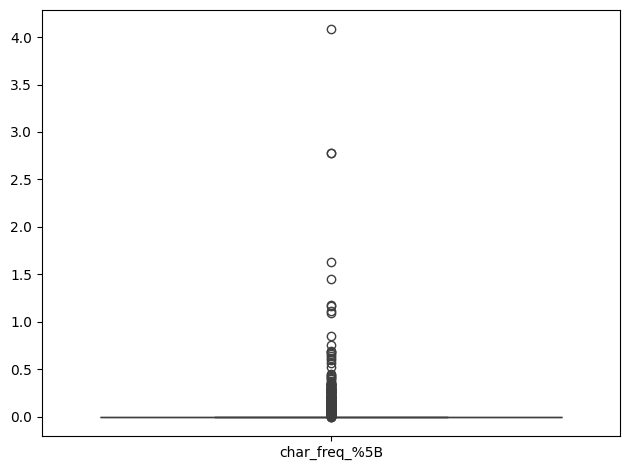

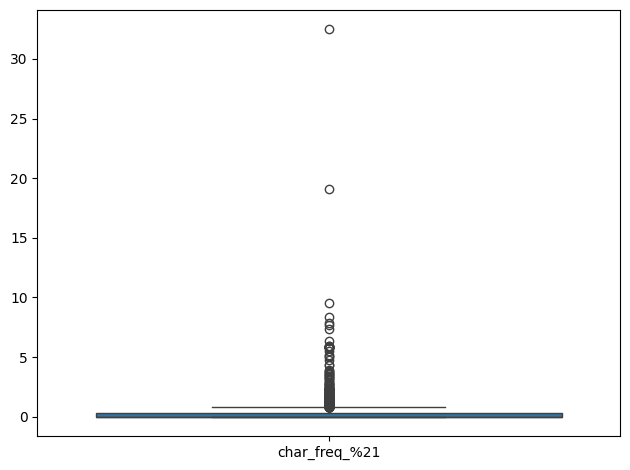

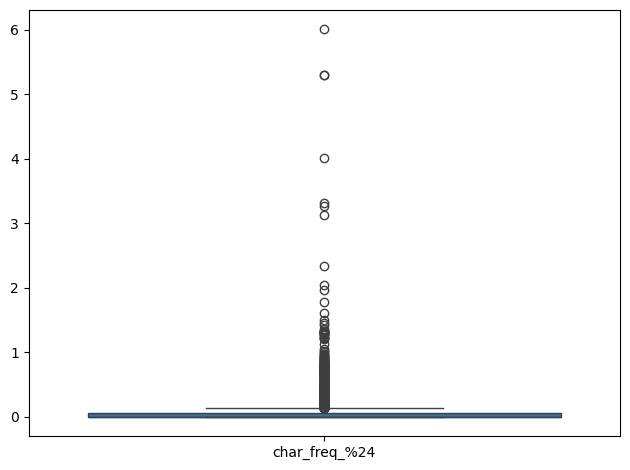

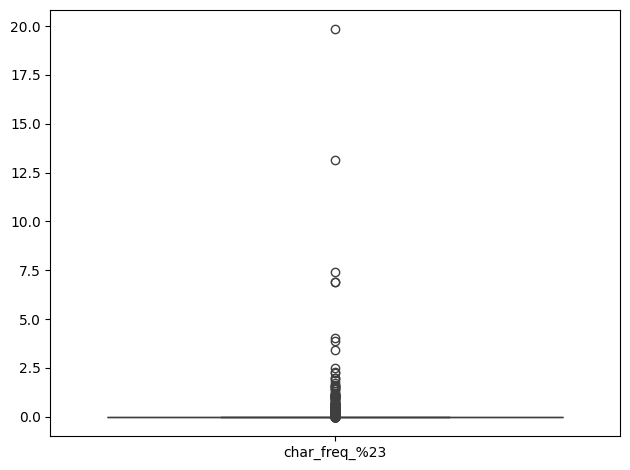

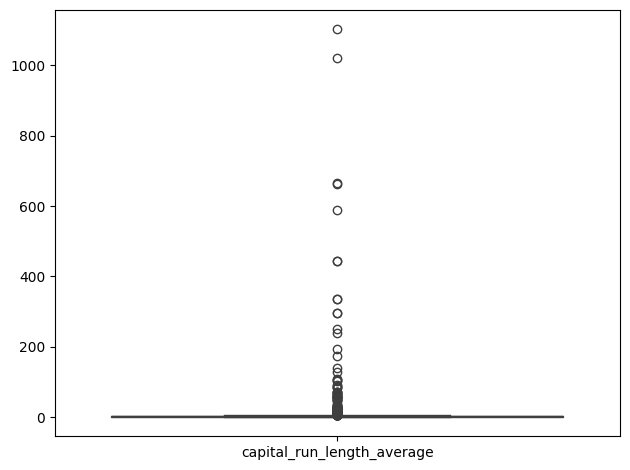

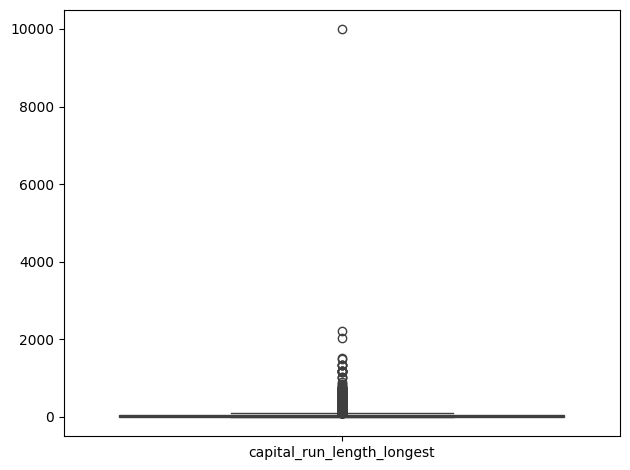

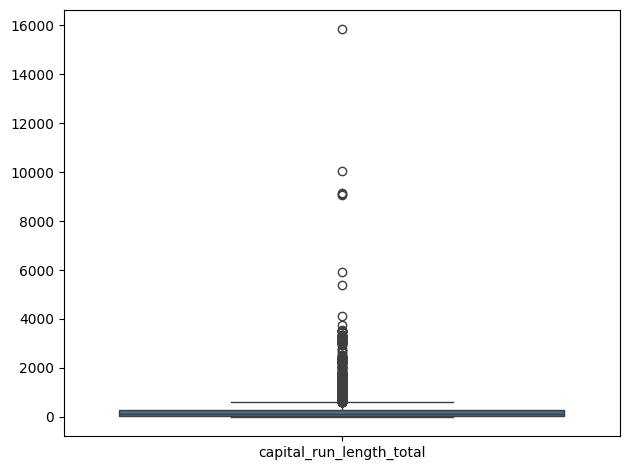

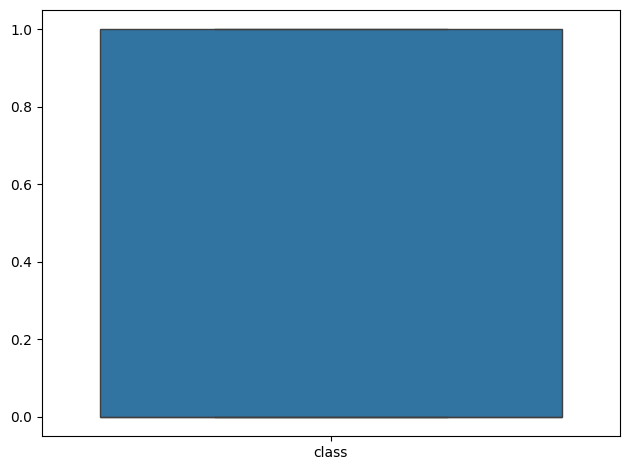

In [6]:
for col in data.columns:
  sns.boxplot(data[[col]])
  plt.tight_layout()
  plt.show()

In [7]:
x = data.iloc[:,:-1]
y = data.iloc[:,-1]

In [8]:
'''for col in x.columns:
  Q1 = x[col].quantile(0.25)
  Q3 = x[col].quantile(0.75)
  IQR = Q3 - Q1
  low = Q1 - 1.5 * IQR
  high = Q3 + 1.5 * IQR

  x[col] = x[col].clip(low, high)'''

'for col in x.columns:\n  Q1 = x[col].quantile(0.25)\n  Q3 = x[col].quantile(0.75)\n  IQR = Q3 - Q1\n  low = Q1 - 1.5 * IQR\n  high = Q3 + 1.5 * IQR\n\n  x[col] = x[col].clip(low, high)'

In [9]:
'''for col in x.columns:
  sns.boxplot(col)
  plt.tight_layout()
  plt.show()'''

'for col in x.columns:\n  sns.boxplot(col)\n  plt.tight_layout()\n  plt.show()'

**(iii) Standarization / Normalization**

In [10]:
x.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191


In [11]:
x_standard = x
standard = StandardScaler()

for col in x_standard:
  x_standard[col] = standard.fit_transform(x_standard[[col]])

x_standard.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,-0.342434,0.330885,0.712859,-0.0469,0.011565,-0.350266,-0.291794,-0.262562,-0.323302,-0.371364,...,-0.111546,-0.158453,-0.514307,-0.155198,0.624007,-0.308355,-0.103048,-0.045247,0.045298,-0.008724
1,0.345359,0.051909,0.435130,-0.0469,-0.256117,0.672399,0.244743,-0.088010,-0.323302,1.086711,...,-0.111546,-0.158453,-0.026007,-0.155198,0.126203,0.423783,0.008763,-0.002443,0.250563,1.228324
2,-0.145921,-0.165072,0.851723,-0.0469,1.364846,0.343685,0.193644,0.036670,1.974017,0.016422,...,-0.111546,-0.117376,0.014684,-0.155198,0.008496,0.440053,-0.079754,0.145921,2.221106,3.258733
3,-0.342434,-0.165072,-0.556761,-0.0469,0.472573,-0.350266,0.500237,1.308402,0.789462,0.605857,...,-0.111546,-0.158453,-0.007511,-0.155198,-0.161934,-0.308355,-0.103048,-0.052150,-0.062466,-0.152222
4,-0.342434,-0.165072,-0.556761,-0.0469,0.472573,-0.350266,0.500237,1.308402,0.789462,0.605857,...,-0.111546,-0.158453,-0.014910,-0.155198,-0.164387,-0.308355,-0.103048,-0.052150,-0.062466,-0.152222


In [12]:
x_norm = x
normalize = MinMaxScaler()

for col in x_norm:
  x_norm[col] = normalize.fit_transform(x_norm[[col]])

x_norm.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.000000,0.044818,0.125490,0.0,0.032,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.023955,0.000000,0.000000,0.002502,0.006007,0.017487
1,0.046256,0.019608,0.098039,0.0,0.014,0.047619,0.028886,0.006301,0.000000,0.051705,...,0.0,0.000000,0.013536,0.0,0.011454,0.029985,0.002421,0.003735,0.010012,0.064836
2,0.013216,0.000000,0.139216,0.0,0.123,0.032313,0.026135,0.010801,0.121673,0.013751,...,0.0,0.002281,0.014664,0.0,0.008498,0.030651,0.000504,0.008008,0.048458,0.142551
3,0.000000,0.000000,0.000000,0.0,0.063,0.000000,0.042641,0.056706,0.058935,0.034653,...,0.0,0.000000,0.014048,0.0,0.004218,0.000000,0.000000,0.002303,0.003905,0.011995
4,0.000000,0.000000,0.000000,0.0,0.063,0.000000,0.042641,0.056706,0.058935,0.034653,...,0.0,0.000000,0.013843,0.0,0.004157,0.000000,0.000000,0.002303,0.003905,0.011995


#**Splitting**

In [13]:
x_train,x_test,y_train,y_test = train_test_split(x_norm,y,test_size=0.5)
x_val,x_test,y_val,y_test = train_test_split(x_test,y_test,test_size=0.2)

In [14]:
print(x_train.shape,y_train.shape)
print(x_val.shape,y_val.shape)
print(x_test.shape,y_test.shape)

(2300, 57) (2300,)
(1840, 57) (1840,)
(461, 57) (461,)


#**Model Building**

#**(i) KNN**


 ------ K = 1 ------


Accuracy Score of Testing  : 0.9023861171366594
Precision Score of Testing : 0.8666666666666667
F1 Score of Testing        : 0.8825065274151436
Recall Score of Testing    : 0.898936170212766

Confusion Matrix :- 
 [[1417    0]
 [   0  883]]


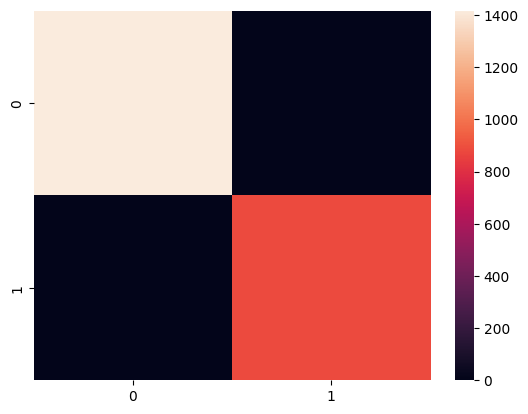

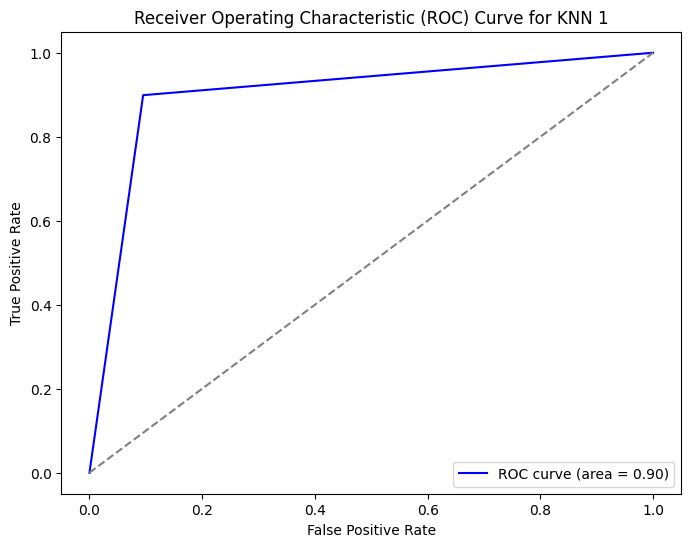


 ------ K = 3 ------


Accuracy Score of Testing  : 0.8872017353579176
Precision Score of Testing : 0.8578947368421053
F1 Score of Testing        : 0.8624338624338624
Recall Score of Testing    : 0.8670212765957447

Confusion Matrix :- 
 [[1355   62]
 [  74  809]]


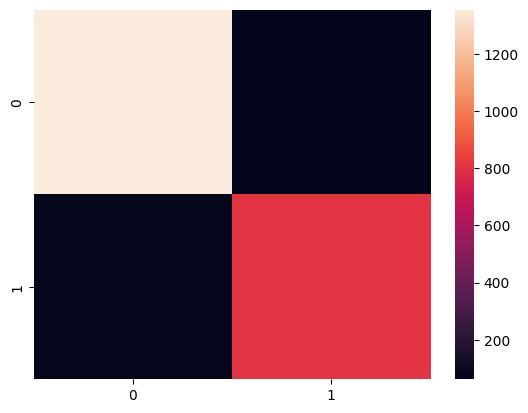

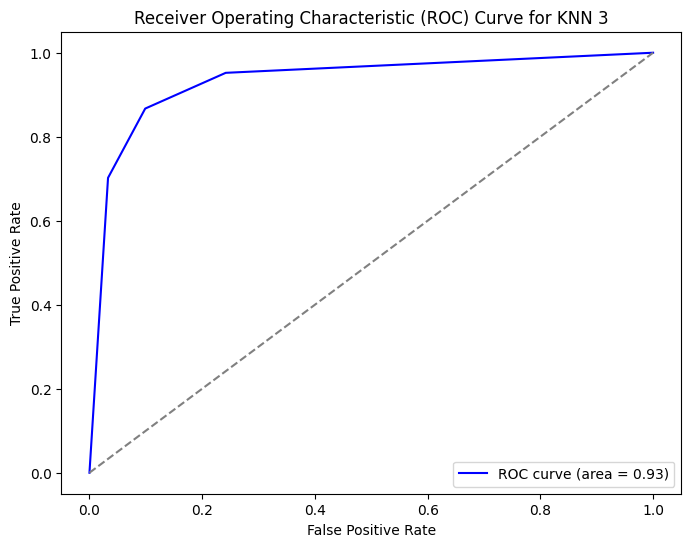


 ------ K = 5 ------


Accuracy Score of Testing  : 0.8893709327548807
Precision Score of Testing : 0.8702702702702703
F1 Score of Testing        : 0.8632707774798928
Recall Score of Testing    : 0.8563829787234043

Confusion Matrix :- 
 [[1347   70]
 [ 105  778]]


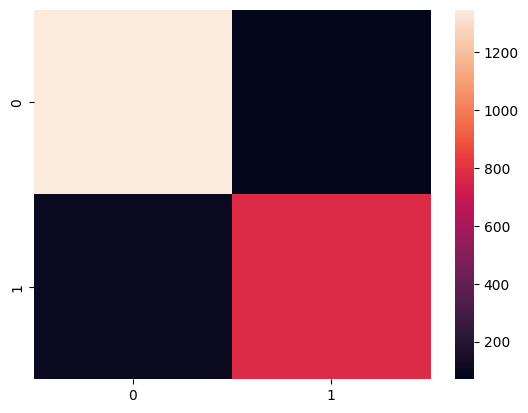

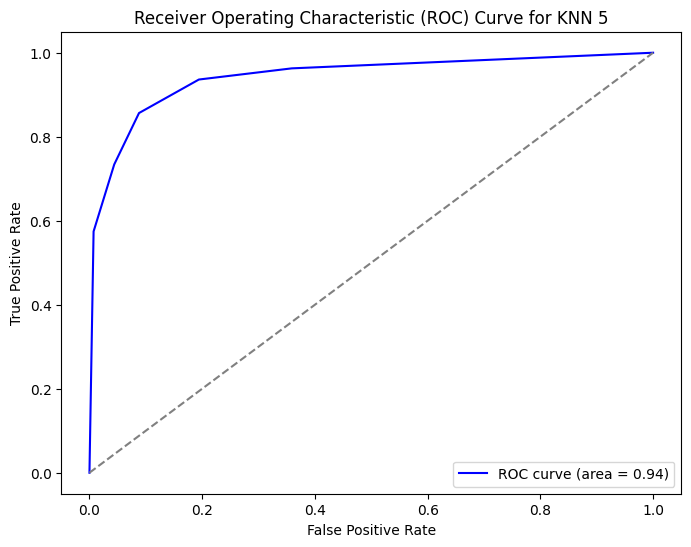


 ------ K = 7 ------


Accuracy Score of Testing  : 0.8828633405639913
Precision Score of Testing : 0.8681318681318682
F1 Score of Testing        : 0.8540540540540541
Recall Score of Testing    : 0.8404255319148937

Confusion Matrix :- 
 [[1338   79]
 [ 132  751]]


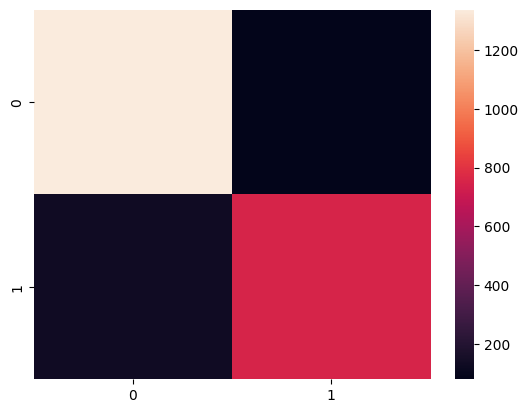

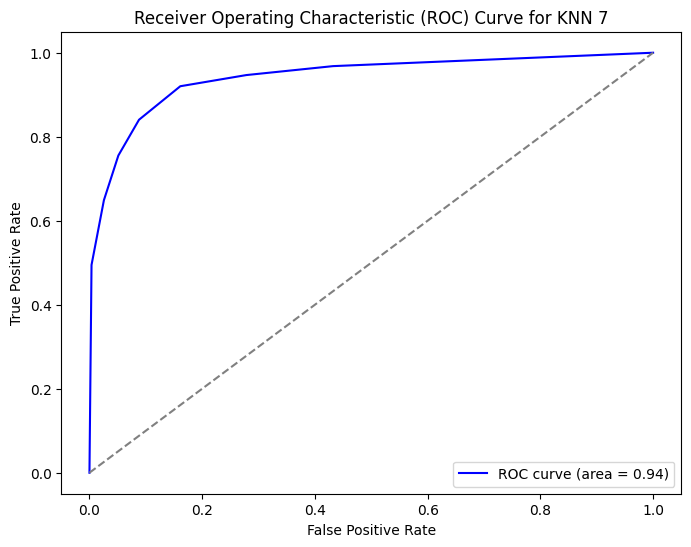

In [15]:
for k in [1,3,5,7]:
  print(f"\n ------ K = {k} ------\n")
  knn = KNeighborsClassifier(n_neighbors=k, algorithm='auto')
  knn.fit(x_train,y_train)
  y_pre_train = knn.predict(x_train)
  con_train_knn = confusion_matrix(y_train,y_pre_train)
  #sns.heatmap(con_train_knn)

  accuracy_knn_train = accuracy_score(y_train,y_pre_train)
  precision_knn_train = precision_score(y_train,y_pre_train)
  f1_knn_train = f1_score(y_train,y_pre_train)
  recall_knn_train = recall_score(y_train,y_pre_train)

  '''print("Accuracy Score of Training  :",accuracy_knn_train)
  print("Precision Score of Training :",precision_knn_train)
  print("F1 Score of Training        :",f1_knn_train)
  print("Recall Score of Training    :",recall_knn_train)
  print("\nConfusion Matrix :- \n",con_train_knn)'''

  y_pre_test = knn.predict(x_test)
  con_test_knn = confusion_matrix(y_train,y_pre_train)
  sns.heatmap(con_test_knn)

  accuracy_knn_test = accuracy_score(y_test,y_pre_test)
  precision_knn_test = precision_score(y_test,y_pre_test)
  f1_knn_test = f1_score(y_test,y_pre_test)
  recall_knn_test = recall_score(y_test,y_pre_test)

  print("\nAccuracy Score of Testing  :",accuracy_knn_test)
  print("Precision Score of Testing :",precision_knn_test)
  print("F1 Score of Testing        :",f1_knn_test)
  print("Recall Score of Testing    :",recall_knn_test)
  print("\nConfusion Matrix :- \n",con_test_knn)

  y_probs_knn = knn.predict_proba(x_test)[:, 1]

  # Calculate FPR and TPR for different thresholds
  fpr_knn, tpr_knn, thresholds = roc_curve(y_test, y_probs_knn)

  # Calculate the AUC
  roc_auc_knn = auc(fpr_knn, tpr_knn)

  # Plot the ROC curve
  plt.figure(figsize=(8, 6))
  plt.plot(fpr_knn, tpr_knn, color='b', label=f'ROC curve (area = {roc_auc_knn:.2f})')
  plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for KNN {k}')
  plt.legend(loc='lower right')
  plt.show()

#**Grid Search CV**

In [16]:
params = {
           'n_neighbors':[1,3,5,7],
           'algorithm':['auto','ball_tree','kd_tree']
         }

grid = GridSearchCV(KNeighborsClassifier(),param_grid = params,scoring='roc_auc', cv = 5)
grid.fit(x_val,y_val)
print(grid.best_params_)
print(grid.best_score_)

{'algorithm': 'auto', 'n_neighbors': 7}
0.9373233878420282


#**Randomized Search CV**

In [17]:
params = {
           'n_neighbors':[1,3,5,7],
           'algorithm':['auto','ball_tree','kd_tree']
         }

random = RandomizedSearchCV(KNeighborsClassifier(),param_distributions = params,scoring='roc_auc', cv = 5)
random.fit(x_val,y_val)
print(random.best_params_)
print(random.best_score_)

{'n_neighbors': 7, 'algorithm': 'kd_tree'}
0.9373233878420282


#**(ii) Ball Tree**


 ------ K = 1 ------


Duration for Ball Tree with k = 1 is 0.0107574462890625


Accuracy Score of Testing  : 0.9023861171366594
Precision Score of Testing : 0.8666666666666667
F1 Score of Testing        : 0.8825065274151436
Recall Score of Testing    : 0.898936170212766

Confusion Matrix :- 
 [[1417    0]
 [   0  883]]


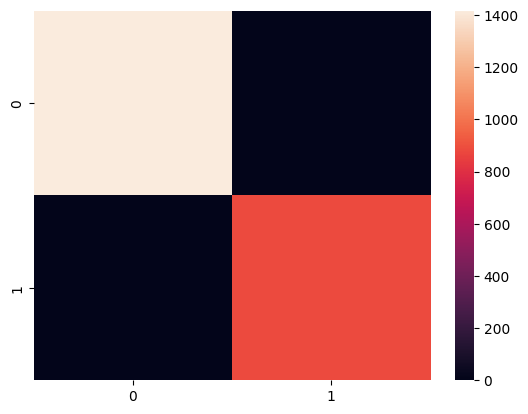

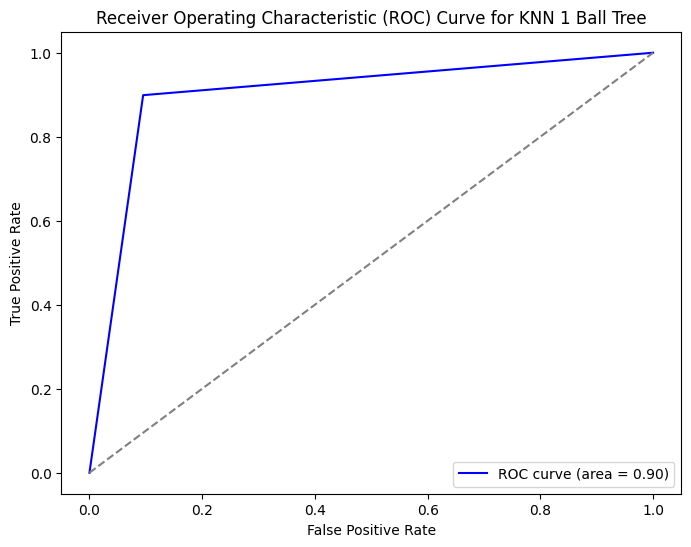


 ------ K = 3 ------


Duration for Ball Tree with k = 3 is 0.024854183197021484


Accuracy Score of Testing  : 0.8872017353579176
Precision Score of Testing : 0.8578947368421053
F1 Score of Testing        : 0.8624338624338624
Recall Score of Testing    : 0.8670212765957447

Confusion Matrix :- 
 [[1355   62]
 [  74  809]]


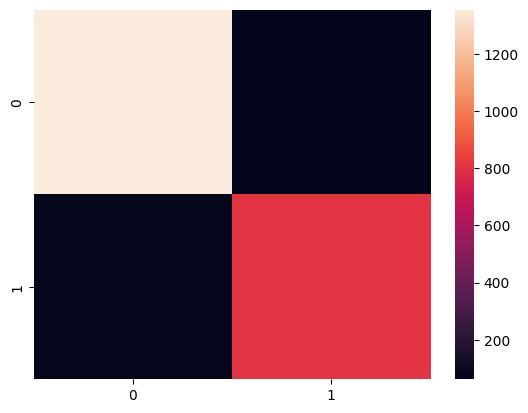

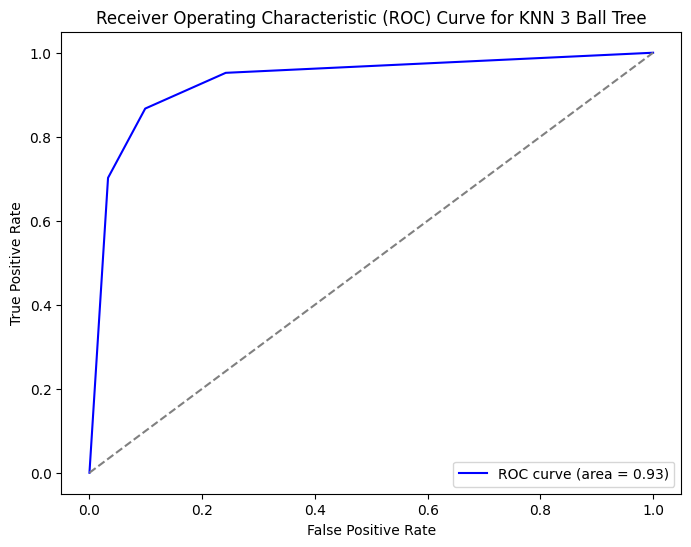


 ------ K = 5 ------


Duration for Ball Tree with k = 5 is 0.024918317794799805


Accuracy Score of Testing  : 0.8893709327548807
Precision Score of Testing : 0.8702702702702703
F1 Score of Testing        : 0.8632707774798928
Recall Score of Testing    : 0.8563829787234043

Confusion Matrix :- 
 [[1347   70]
 [ 105  778]]


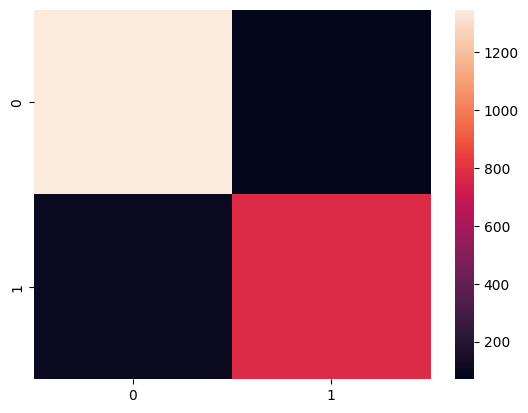

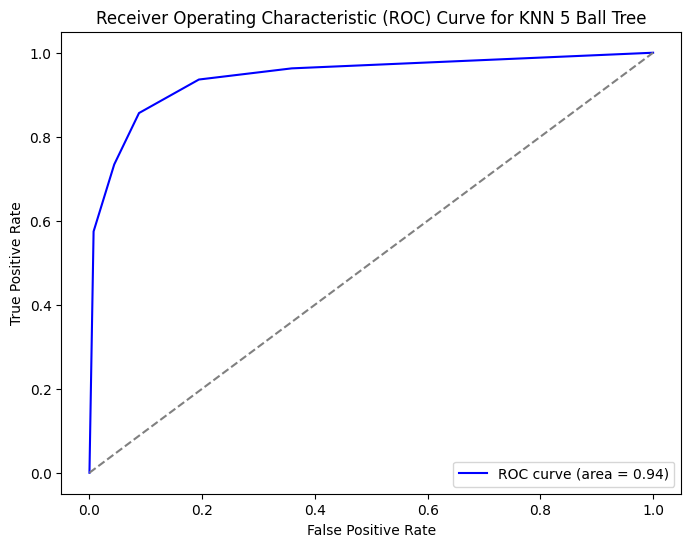


 ------ K = 7 ------


Duration for Ball Tree with k = 7 is 0.028620481491088867


Accuracy Score of Testing  : 0.8828633405639913
Precision Score of Testing : 0.8681318681318682
F1 Score of Testing        : 0.8540540540540541
Recall Score of Testing    : 0.8404255319148937

Confusion Matrix :- 
 [[1338   79]
 [ 132  751]]


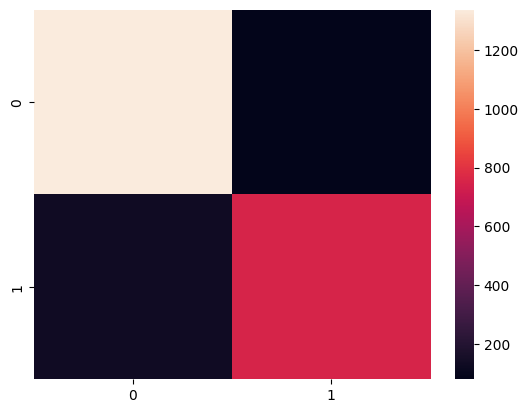

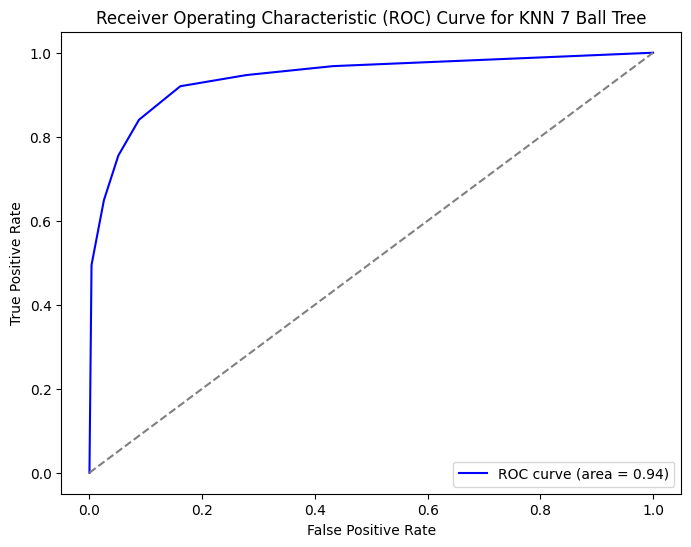

In [18]:
for k in [1,3,5,7]:
  print(f"\n ------ K = {k} ------\n")
  knn = KNeighborsClassifier(n_neighbors=k, algorithm='ball_tree')
  start_time = time.time()
  knn.fit(x_train,y_train)
  end_time = time.time()
  y_pre_train = knn.predict(x_train)
  con_train_knn = confusion_matrix(y_train,y_pre_train)
  #sns.heatmap(con_train_knn)

  accuracy_knn_train = accuracy_score(y_train,y_pre_train)
  precision_knn_train = precision_score(y_train,y_pre_train)
  f1_knn_train = f1_score(y_train,y_pre_train)
  recall_knn_train = recall_score(y_train,y_pre_train)

  print(f"\nDuration for Ball Tree with k = {k} is {end_time-start_time}\n")

  '''print("Accuracy Score of Training  :",accuracy_knn_train)
  print("Precision Score of Training :",precision_knn_train)
  print("F1 Score of Training        :",f1_knn_train)
  print("Recall Score of Training    :",recall_knn_train)
  print("\nConfusion Matrix :- \n",con_train_knn)'''

  y_pre_test = knn.predict(x_test)
  con_test_knn = confusion_matrix(y_train,y_pre_train)
  sns.heatmap(con_test_knn)

  accuracy_knn_test = accuracy_score(y_test,y_pre_test)
  precision_knn_test = precision_score(y_test,y_pre_test)
  f1_knn_test = f1_score(y_test,y_pre_test)
  recall_knn_test = recall_score(y_test,y_pre_test)

  print("\nAccuracy Score of Testing  :",accuracy_knn_test)
  print("Precision Score of Testing :",precision_knn_test)
  print("F1 Score of Testing        :",f1_knn_test)
  print("Recall Score of Testing    :",recall_knn_test)
  print("\nConfusion Matrix :- \n",con_test_knn)

  y_probs_knn = knn.predict_proba(x_test)[:, 1]

  # Calculate FPR and TPR for different thresholds
  fpr_knn, tpr_knn, thresholds = roc_curve(y_test, y_probs_knn)

  # Calculate the AUC
  roc_auc_knn = auc(fpr_knn, tpr_knn)

  # Plot the ROC curve
  plt.figure(figsize=(8, 6))
  plt.plot(fpr_knn, tpr_knn, color='b', label=f'ROC curve (area = {roc_auc_knn:.2f})')
  plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for KNN {k} Ball Tree')
  plt.legend(loc='lower right')
  plt.show()

#**(iii) KD Tree**


 ------ K = 1 ------

Duration for KD Tree with k = 1 is 0.015688419342041016


Accuracy Score of Testing  : 0.9023861171366594
Precision Score of Testing : 0.8666666666666667
F1 Score of Testing        : 0.8825065274151436
Recall Score of Testing    : 0.898936170212766

Confusion Matrix :- 
 [[1417    0]
 [   0  883]]


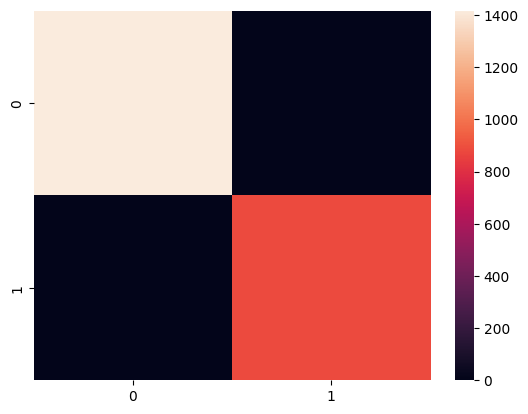

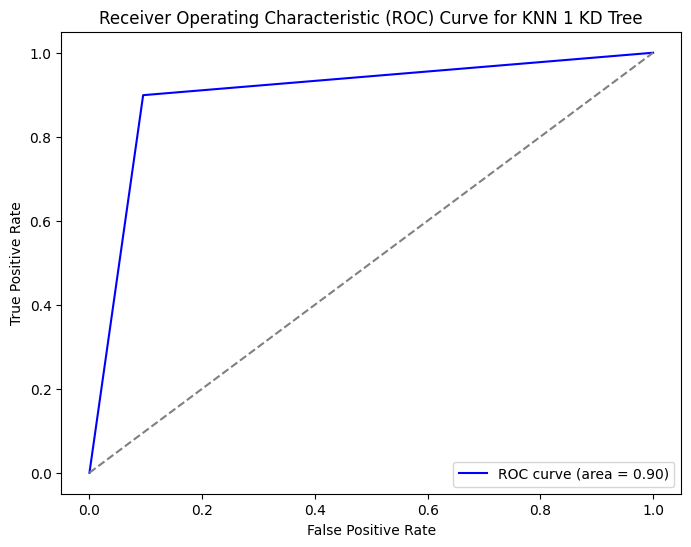


 ------ K = 3 ------

Duration for KD Tree with k = 3 is 0.026271343231201172


Accuracy Score of Testing  : 0.8872017353579176
Precision Score of Testing : 0.8578947368421053
F1 Score of Testing        : 0.8624338624338624
Recall Score of Testing    : 0.8670212765957447

Confusion Matrix :- 
 [[1355   62]
 [  74  809]]


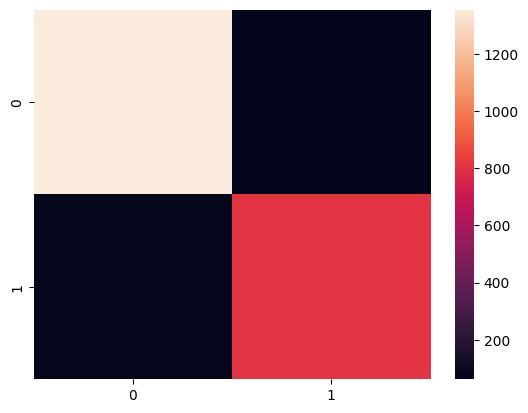

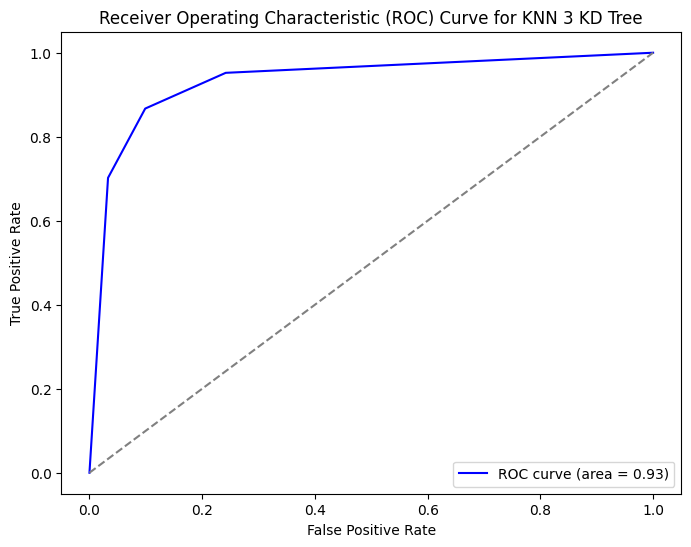


 ------ K = 5 ------

Duration for KD Tree with k = 5 is 0.02123546600341797


Accuracy Score of Testing  : 0.8893709327548807
Precision Score of Testing : 0.8702702702702703
F1 Score of Testing        : 0.8632707774798928
Recall Score of Testing    : 0.8563829787234043

Confusion Matrix :- 
 [[1347   70]
 [ 105  778]]


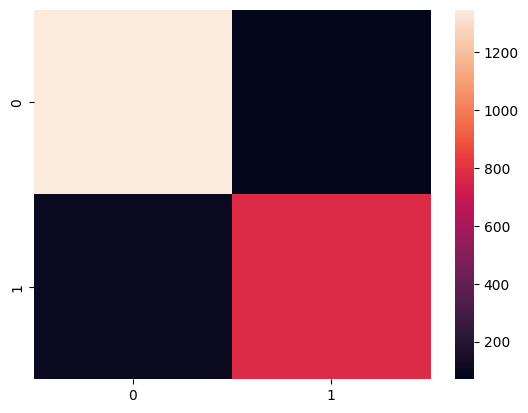

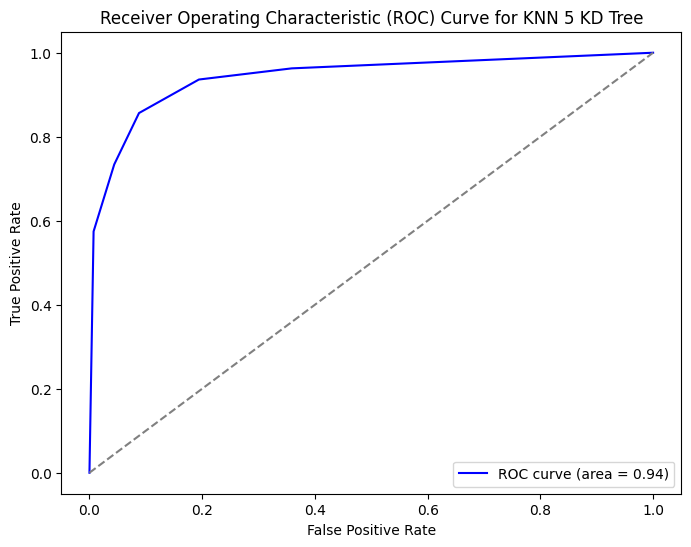


 ------ K = 7 ------

Duration for KD Tree with k = 7 is 0.02454543113708496


Accuracy Score of Testing  : 0.8828633405639913
Precision Score of Testing : 0.8681318681318682
F1 Score of Testing        : 0.8540540540540541
Recall Score of Testing    : 0.8404255319148937

Confusion Matrix :- 
 [[1338   79]
 [ 132  751]]


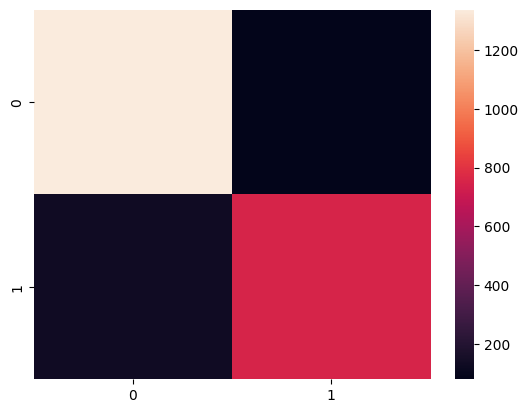

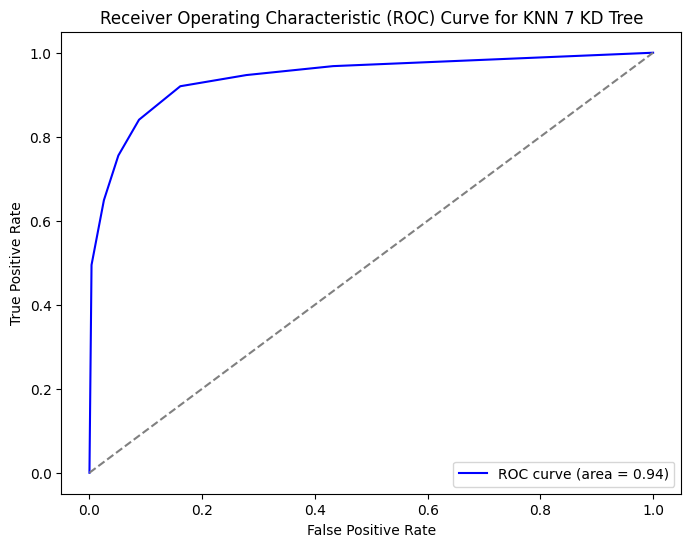

In [19]:
for k in [1,3,5,7]:
  print(f"\n ------ K = {k} ------\n")
  knn = KNeighborsClassifier(n_neighbors=k, algorithm='kd_tree')
  start_time = time.time()
  knn.fit(x_train,y_train)
  end_time = time.time()
  y_pre_train = knn.predict(x_train)
  con_train_knn = confusion_matrix(y_train,y_pre_train)
  #sns.heatmap(con_train_knn)

  print(f"Duration for KD Tree with k = {k} is {end_time - start_time}\n")

  accuracy_knn_train = accuracy_score(y_train,y_pre_train)
  precision_knn_train = precision_score(y_train,y_pre_train)
  f1_knn_train = f1_score(y_train,y_pre_train)
  recall_knn_train = recall_score(y_train,y_pre_train)

  '''print("Accuracy Score of Training  :",accuracy_knn_train)
  print("Precision Score of Training :",precision_knn_train)
  print("F1 Score of Training        :",f1_knn_train)
  print("Recall Score of Training    :",recall_knn_train)
  print("\nConfusion Matrix :- \n",con_train_knn)'''

  y_pre_test = knn.predict(x_test)
  con_test_knn = confusion_matrix(y_train,y_pre_train)
  sns.heatmap(con_test_knn)

  accuracy_knn_test = accuracy_score(y_test,y_pre_test)
  precision_knn_test = precision_score(y_test,y_pre_test)
  f1_knn_test = f1_score(y_test,y_pre_test)
  recall_knn_test = recall_score(y_test,y_pre_test)

  print("\nAccuracy Score of Testing  :",accuracy_knn_test)
  print("Precision Score of Testing :",precision_knn_test)
  print("F1 Score of Testing        :",f1_knn_test)
  print("Recall Score of Testing    :",recall_knn_test)
  print("\nConfusion Matrix :- \n",con_test_knn)

  y_probs_knn = knn.predict_proba(x_test)[:, 1]

  # Calculate FPR and TPR for different thresholds
  fpr_knn, tpr_knn, thresholds = roc_curve(y_test, y_probs_knn)

  # Calculate the AUC
  roc_auc_knn = auc(fpr_knn, tpr_knn)

  # Plot the ROC curve
  plt.figure(figsize=(8, 6))
  plt.plot(fpr_knn, tpr_knn, color='b', label=f'ROC curve (area = {roc_auc_knn:.2f})')
  plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for KNN {k} KD Tree')
  plt.legend(loc='lower right')
  plt.show()

#**Cross validation**


----- Fold ------

Accuracy Score of Testing  : 0.8849077090119435
Precision Score of Testing : 0.8796791443850267
F1 Score of Testing        : 0.8612565445026178
Recall Score of Testing    : 0.8435897435897436

Confusion Matrix :- 
 [[2138  119]
 [ 167 1256]]


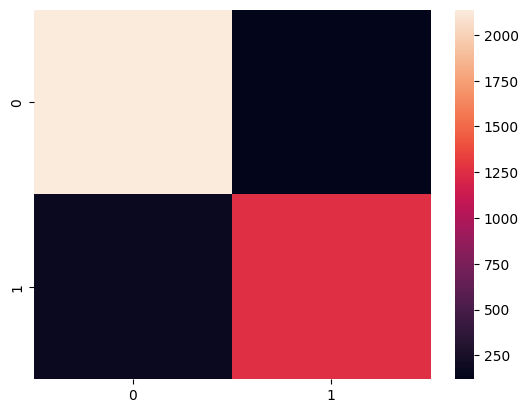

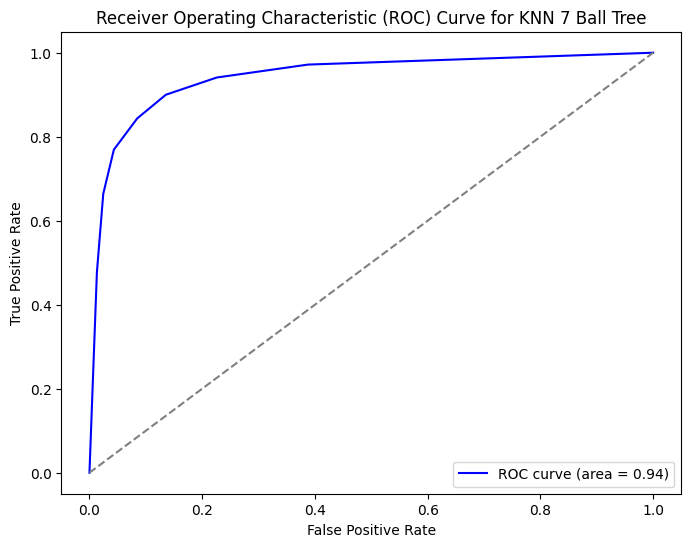


----- Fold ------

Accuracy Score of Testing  : 0.8967391304347826
Precision Score of Testing : 0.8760563380281691
F1 Score of Testing        : 0.8675034867503487
Recall Score of Testing    : 0.8591160220994475

Confusion Matrix :- 
 [[2117  113]
 [ 168 1283]]


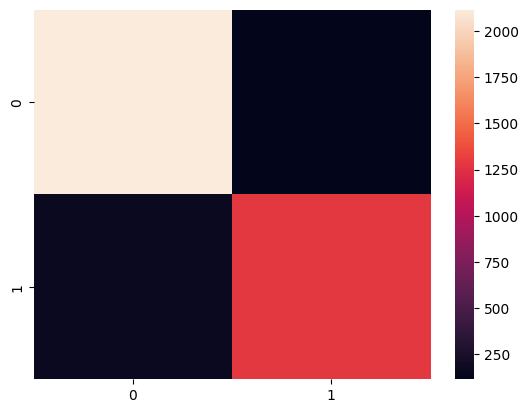

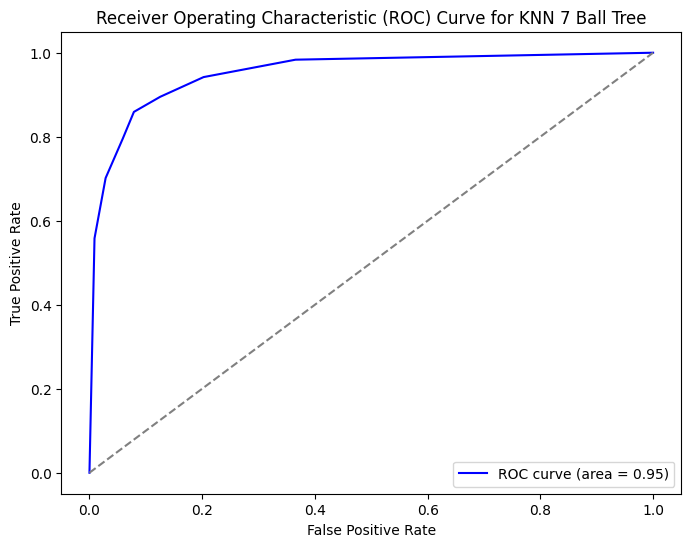


----- Fold ------

Accuracy Score of Testing  : 0.8967391304347826
Precision Score of Testing : 0.884272997032641
F1 Score of Testing        : 0.8625180897250362
Recall Score of Testing    : 0.8418079096045198

Confusion Matrix :- 
 [[2093  129]
 [ 180 1279]]


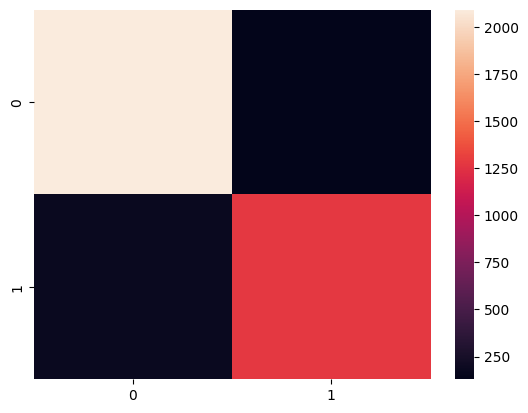

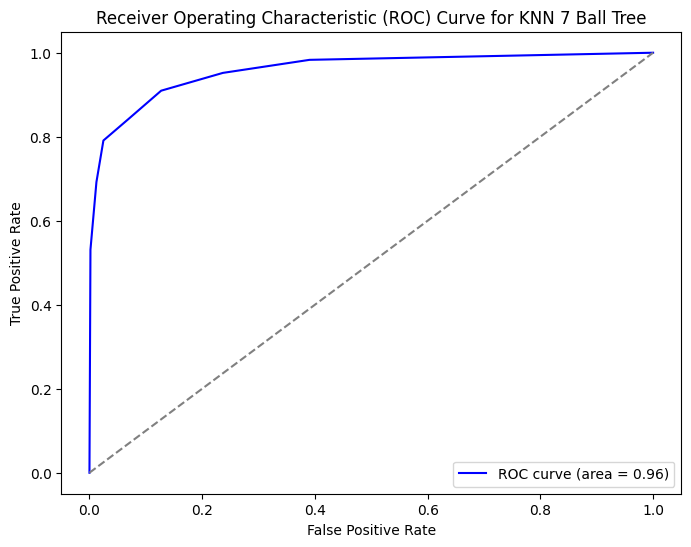


----- Fold ------

Accuracy Score of Testing  : 0.9043478260869565
Precision Score of Testing : 0.8846153846153846
F1 Score of Testing        : 0.8717201166180758
Recall Score of Testing    : 0.8591954022988506

Confusion Matrix :- 
 [[2087  129]
 [ 167 1298]]


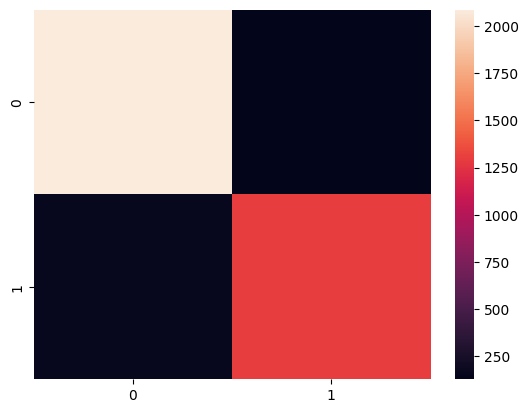

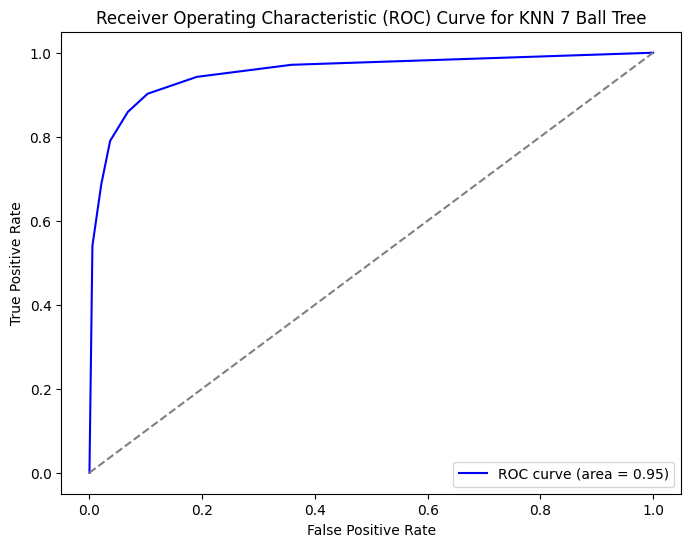


----- Fold ------

Accuracy Score of Testing  : 0.9032608695652173
Precision Score of Testing : 0.8947368421052632
F1 Score of Testing        : 0.8730385164051355
Recall Score of Testing    : 0.8523676880222841

Confusion Matrix :- 
 [[2103  124]
 [ 176 1278]]


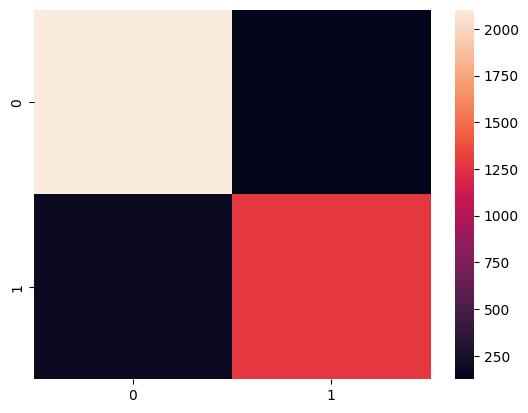

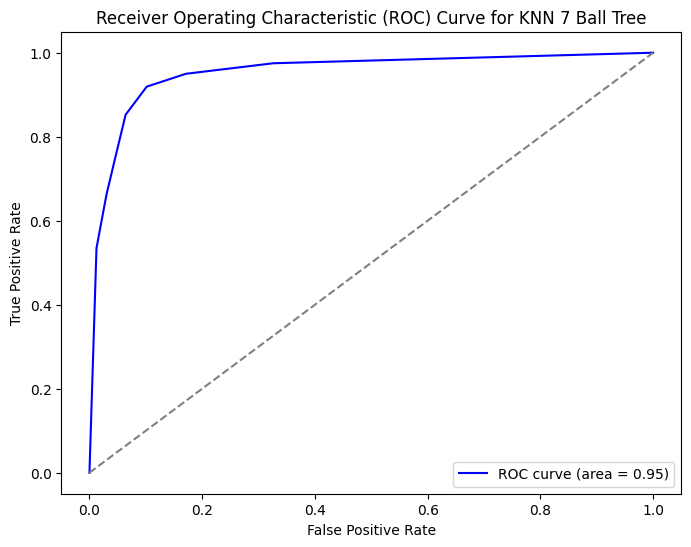

In [20]:
from sklearn.model_selection import KFold

knn = KNeighborsClassifier(n_neighbors = 7,algorithm = 'ball_tree')
kf = KFold(n_splits=5,shuffle=True,random_state=42)

accuracy = []
precision = []
f1 = []
recall = []
area = []

for train_index,test_index in kf.split(x):

  x_train,x_test = x_norm.iloc[train_index],x_norm.iloc[test_index]
  y_train,y_test = y.iloc[train_index],y.iloc[test_index]

  print("\n----- Fold ------")

  knn.fit(x_train,y_train)
  y_pre_train = knn.predict(x_train)
  con_train_knn = confusion_matrix(y_train,y_pre_train)
  #sns.heatmap(con_train_knn)

  accuracy_knn_train = accuracy_score(y_train,y_pre_train)
  precision_knn_train = precision_score(y_train,y_pre_train)
  f1_knn_train = f1_score(y_train,y_pre_train)
  recall_knn_train = recall_score(y_train,y_pre_train)

  '''print("Accuracy Score of Training  :",accuracy_knn_train)
  print("Precision Score of Training :",precision_knn_train)
  print("F1 Score of Training        :",f1_knn_train)
  print("Recall Score of Training    :",recall_knn_train)
  print("\nConfusion Matrix :- \n",con_train_knn)'''

  y_pre_test = knn.predict(x_test)
  con_test_knn = confusion_matrix(y_train,y_pre_train)
  sns.heatmap(con_test_knn)

  accuracy_knn_test = accuracy_score(y_test,y_pre_test)
  precision_knn_test = precision_score(y_test,y_pre_test)
  f1_knn_test = f1_score(y_test,y_pre_test)
  recall_knn_test = recall_score(y_test,y_pre_test)

  print("\nAccuracy Score of Testing  :",accuracy_knn_test)
  print("Precision Score of Testing :",precision_knn_test)
  print("F1 Score of Testing        :",f1_knn_test)
  print("Recall Score of Testing    :",recall_knn_test)
  print("\nConfusion Matrix :- \n",con_test_knn)

  y_probs_knn = knn.predict_proba(x_test)[:, 1]

  # Calculate FPR and TPR for different thresholds
  fpr_knn, tpr_knn, thresholds = roc_curve(y_test, y_probs_knn)

  # Calculate the AUC
  roc_auc_knn = auc(fpr_knn, tpr_knn)

  accuracy.append(accuracy_knn_test)
  precision.append(precision_knn_test)
  f1.append(f1_knn_test)
  recall.append(recall_knn_test)
  area.append(roc_auc_knn)

  # Plot the ROC curve
  plt.figure(figsize=(8, 6))
  plt.plot(fpr_knn, tpr_knn, color='b', label=f'ROC curve (area = {roc_auc_knn:.2f})')
  plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for KNN {k} Ball Tree')
  plt.legend(loc='lower right')
  plt.show()

In [21]:
df = pd.DataFrame({
    'KFold': list(range(1, 6)),
    'accuracy': accuracy,
    'precision': precision,
    'f1': f1,
    'recall': recall,
    'auc': area
})

mean_row = pd.DataFrame([{
    'KFold': 'Mean',
    'accuracy': np.mean(accuracy),
    'precision': np.mean(precision),
    'f1': np.mean(f1),
    'recall': np.mean(recall),
    'auc': np.mean(area)
}])

df = pd.concat([df, mean_row], ignore_index=True)

print("K Fold for KNN 7 :-\n")
df

K Fold for KNN 7 :-



,KFold,accuracy,precision,f1,recall,auc
0,1,0.884908,0.879679,0.861257,0.843590,0.942356
1,2,0.896739,0.876056,0.867503,0.859116,0.951833
2,3,0.896739,0.884273,0.862518,0.841808,0.958291
3,4,0.904348,0.884615,0.871720,0.859195,0.953056
4,5,0.903261,0.894737,0.873039,0.852368,0.952408
5,Mean,0.897199,0.883872,0.867207,0.851215,0.951589
